In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
CANDIDATES = [ROOT] + list(ROOT.parents)
PROJECT_ROOT = next((p for p in CANDIDATES if (p / 'src').exists()), ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 02 Preprocess va Feature
Lam sach va tao dac trung cho bai toan mining + forecasting.

In [2]:
from src.data.loader import load_all_coins
from src.data.cleaner import clean_crypto_dataframe
from src.features.builder import build_features
raw_df = load_all_coins(str(PROJECT_ROOT / 'data' / 'raw'))
clean_df = clean_crypto_dataframe(raw_df)
feat_df = build_features(clean_df)
feat_df.shape

(36042, 37)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

palette = {"stormcloud": "#4F6367", "beige": "#EEF5DB", "sunset": "#FE5F55"}
sns.set_theme(style="whitegrid")

In [4]:
raw_df.shape, clean_df.shape, feat_df.shape

((37082, 11), (37082, 12), (36042, 37))

In [5]:
feature_cols = [c for c in feat_df.columns if c in [
    "return_1d","return_3d","return_7d","log_return_1d","hl_spread","oc_spread",
    "ma_7","ma_14","ma_30","std_7","std_14","std_30",
    "volatility_7","volatility_14","volatility_30","momentum_7","momentum_14","momentum_30","rsi_14"
]]
feat_df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
return_1d,36042.0,0.004015,0.067143,-4.600549e-01,-0.022024,0.000000,0.023869,0.967635
return_3d,36042.0,0.012973,0.132125,-5.718456e-01,-0.039396,0.000000,0.045198,4.713382
return_7d,36042.0,0.033959,0.252117,-5.821406e-01,-0.063112,0.000030,0.078518,7.442383
log_return_1d,36042.0,0.001878,0.064776,-6.162879e-01,-0.022270,0.000000,0.023589,0.676832
hl_spread,36042.0,0.078645,0.112292,0.000000e+00,0.031836,0.057640,0.098892,15.192120
oc_spread,36042.0,0.003900,0.066995,-4.590911e-01,-0.021889,0.000000,0.023831,0.979200
ma_7,36042.0,1004.702590,5133.680739,8.971896e-05,0.071589,1.001622,32.710763,61754.598907
std_7,36042.0,44.310635,261.986714,0.000000e+00,0.001803,0.034346,1.567949,4547.028590
volatility_7,36042.0,0.051625,0.049001,0.000000e+00,0.024166,0.041480,0.065392,1.372726
momentum_7,36042.0,0.033959,0.252117,-5.821406e-01,-0.063112,0.000030,0.078518,7.442383


In [6]:
state_table = feat_df.groupby(["state_updown", "state_vol"]).size().reset_index(name="count")
state_table

C:\Users\Admin\AppData\Local\Temp\ipykernel_7064\2842201041.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_table = feat_df.groupby(["state_updown", "state_vol"]).size().reset_index(name="count")


,state_updown,state_vol,count
0,down,low_vol,2098
1,down,mid_vol,5740
2,down,high_vol,10305
3,up,low_vol,1839
4,up,mid_vol,5628
5,up,high_vol,10432


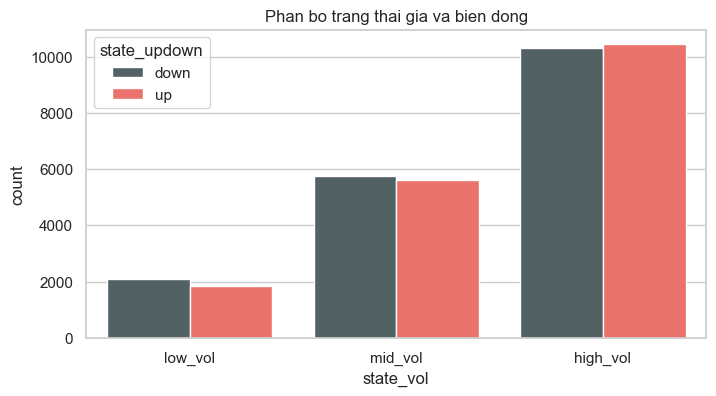

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=feat_df, x="state_vol", hue="state_updown", palette=[palette["stormcloud"], palette["sunset"]], ax=ax)
ax.set_title("Phan bo trang thai gia va bien dong")
plt.show()

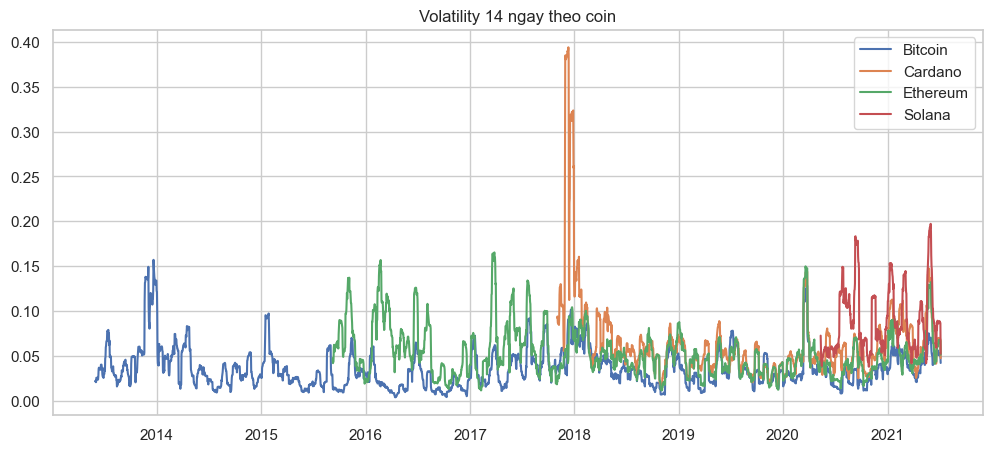

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
subset = feat_df[feat_df["coin"].isin(["Bitcoin", "Ethereum", "Solana", "Cardano"])].copy()
for coin, d in subset.groupby("coin"):
    temp = d.sort_values("date")
    ax.plot(temp["date"], temp["volatility_14"], label=coin, linewidth=1.5)
ax.set_title("Volatility 14 ngay theo coin")
ax.legend()
plt.show()

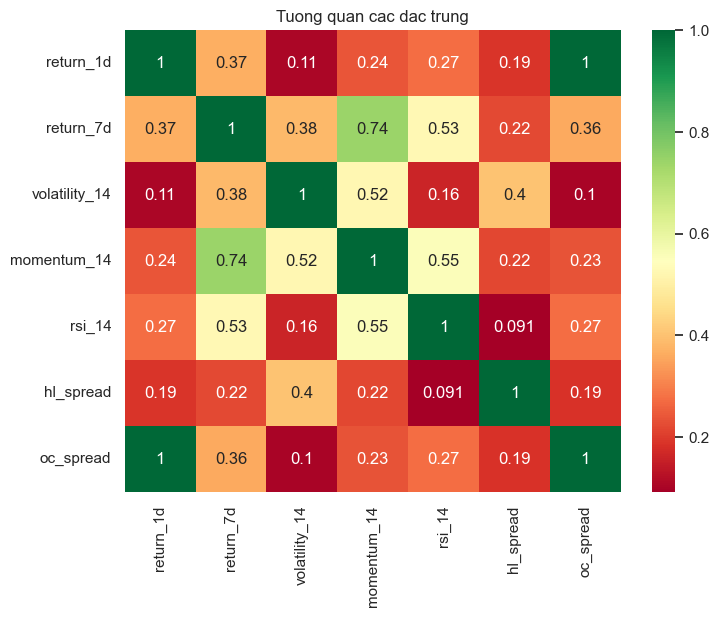

In [9]:
corr_cols = ["return_1d", "return_7d", "volatility_14", "momentum_14", "rsi_14", "hl_spread", "oc_spread"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(feat_df[corr_cols].corr(), annot=True, cmap="RdYlGn", ax=ax)
ax.set_title("Tuong quan cac dac trung")
plt.show()

In [10]:
save_cols = ["date", "coin", "close", "return_1d", "volatility_14", "state_updown", "state_vol", "future_trend_up", "future_return_1d"]
feat_df[save_cols].to_csv("../data/processed/feature_snapshot.csv", index=False)
feat_df[save_cols].head()

,date,coin,close,return_1d,volatility_14,state_updown,state_vol,future_trend_up,future_return_1d
30,2020-11-04 23:59:59,Aave,27.715084,-0.011686,0.061351,down,high_vol,1,0.116923
31,2020-11-05 23:59:59,Aave,30.955627,0.116923,0.066164,up,high_vol,1,0.242341
32,2020-11-06 23:59:59,Aave,38.457441,0.242341,0.091383,up,high_vol,1,0.159851
33,2020-11-07 23:59:59,Aave,44.604900,0.159851,0.099583,up,high_vol,1,0.205011
34,2020-11-08 23:59:59,Aave,53.749379,0.205011,0.110505,up,high_vol,1,0.021156
